In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.inspection import permutation_importance
from catboost import Pool, CatBoostClassifier

In [68]:
pd.set_option('display.max_columns',None)
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/encoded_plus_df.csv'

df = pd.read_csv(url)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')
df['Best of'] = df['Best of'].astype(str)

random_state=42

Separación de conjuntos

In [69]:
weather_cols = ['temperature_2m_mean','apparent_temperature_mean', 'precipitation_sum', 'rain_sum','wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_gusts_10m_mean',
              'wind_speed_10m_mean', 'relative_humidity_2m_mean','relative_humidity_2m_max', 'relative_humidity_2m_min','soil_temperature_0_to_100cm_mean',
              'soil_moisture_0_to_100cm_mean','wind_gusts_10m_min', 'wind_speed_10m_min']
for col in weather_cols:
    df[col] = df[col]*df['is_outdoor']

In [70]:
# Sacamos las variables que revelan información post-partido y también las que encodeamos porque las vamos a usar directamente como categóricas
# La variable 'Location' ahora la podemos liberar también
new_df = df.drop(columns=['Fecha', 'playerA', 'playerB','A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4', 'B4', 'A5','B5', 'setsA', 'setsB', 'setsPartido',
                          'series_level_oe', 'round_encoded', 'is_best_of_5', 'surface_fe','is_outdoor'])

df_no_nulls = new_df.dropna()
X = df_no_nulls.drop(columns=['target'])
y = df_no_nulls['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, random_state=random_state)

cat_features = X_train.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

## Baseline

In [13]:
# Nivel 1 — Mayoría simple (lower bound absoluto)
majority_class = y_train.mode()[0]
baseline_majority = np.full(len(y_test), majority_class)

# Nivel 2 — Tu baseline de ranking (naive sports knowledge)
y_baseline_rank = (X_test['rankA'] < X_test['rankB']).astype(int)

# Nivel 3 — Baseline de odds (upper bound)
y_baseline_odds = (X_test['B365ProbA'] > 0.5).astype(int)

for name, pred in [("Mayoría", baseline_majority),
                   ("Ranking", y_baseline_rank),
                   ("Odds B365", y_baseline_odds)]:
    print(f"{name}: {accuracy_score(y_test, pred)}")

Mayoría: 0.5157860824742269
Ranking: 0.6710695876288659
Odds B365: 0.7313144329896907


## Modelo Full

In [46]:
catboost = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='Accuracy',
    use_best_model=True,
    early_stopping_rounds=500,
    random_seed=42,
    verbose=100
)

catboost.fit(train_pool, eval_set=val_pool)

0:	learn: 0.7028905	test: 0.7011679	best: 0.7011679 (0)	total: 28.6ms	remaining: 57.2s
100:	learn: 0.7041998	test: 0.7039871	best: 0.7076118 (26)	total: 2.64s	remaining: 49.7s
200:	learn: 0.7067177	test: 0.7031816	best: 0.7076118 (26)	total: 5.23s	remaining: 46.8s
300:	learn: 0.7099406	test: 0.7039871	best: 0.7076118 (26)	total: 7.88s	remaining: 44.5s
400:	learn: 0.7147749	test: 0.7051953	best: 0.7076118 (26)	total: 11.2s	remaining: 44.7s
500:	learn: 0.7191057	test: 0.7072090	best: 0.7076118 (26)	total: 13.8s	remaining: 41.2s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.70761176
bestIteration = 26

Shrink model to first 27 iterations.


CatBoostClassifier(early_stopping_rounds=500, eval_metric='Accuracy', iterations=2000, learning_rate=0.01, loss_function='Logloss', random_seed=42, use_best_model=True, verbose=100)

In [47]:
print('\nTRAIN')
y_pred = catboost.predict(X_train)
print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
# print(classification_report(y_train, y_pred))

print('\nTRAIN')
y_pred = catboost.predict(X_val)
print(f'Accuracy: {accuracy_score(y_val, y_pred)}')
# print(classification_report(y_train, y_pred))

print('\nTEST')
y_pred = catboost.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
# print(classification_report(y_test, y_pred))


TRAIN
Accuracy: 0.703394098096485

TRAIN
Accuracy: 0.7076117599677809

TEST
Accuracy: 0.7290592783505154


## Modelo reducido

In [71]:
elo_cols = [i for i in df.columns if 'elo' in i]
otras_cols = ['market_uncertainty','OddsDiffB365','OddsDiffAvg','OddsDiffMax','AvgOddsDiff']

df_red = df[elo_cols + otras_cols + cat_features]

df_red = df_red.dropna()
X = df_red
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, random_state=random_state)

cat_features = X_train.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [73]:
catboost = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.01,
    loss_function='Logloss',
    eval_metric='Accuracy',
    use_best_model=True,
    early_stopping_rounds=500,
    random_seed=42,
    verbose=100
)

catboost.fit(train_pool, eval_set=val_pool)

0:	learn: 0.7047091	test: 0.7077821	best: 0.7077821 (0)	total: 20ms	remaining: 40s
100:	learn: 0.7092820	test: 0.7132296	best: 0.7143969 (15)	total: 1.51s	remaining: 28.5s
200:	learn: 0.7119089	test: 0.7116732	best: 0.7143969 (15)	total: 2.94s	remaining: 26.3s
300:	learn: 0.7151197	test: 0.7108949	best: 0.7143969 (15)	total: 4.38s	remaining: 24.7s
400:	learn: 0.7159953	test: 0.7132296	best: 0.7143969 (15)	total: 6.55s	remaining: 26.1s
500:	learn: 0.7175521	test: 0.7124514	best: 0.7143969 (15)	total: 7.98s	remaining: 23.9s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.7143968872
bestIteration = 15

Shrink model to first 16 iterations.


CatBoostClassifier(early_stopping_rounds=500, eval_metric='Accuracy', iterations=2000, learning_rate=0.01, loss_function='Logloss', random_seed=42, use_best_model=True, verbose=100)

In [74]:
print('\nTRAIN')
y_pred = catboost.predict(X_train)
print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
# print(classification_report(y_train, y_pred))

print('\nTRAIN')
y_pred = catboost.predict(X_val)
print(f'Accuracy: {accuracy_score(y_val, y_pred)}')
# print(classification_report(y_train, y_pred))

print('\nTEST')
y_pred = catboost.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
# print(classification_report(y_test, y_pred))


TRAIN
Accuracy: 0.7066549912434326

TRAIN
Accuracy: 0.7143968871595331

TEST
Accuracy: 0.7136632430750078


## Feature Importance

In [53]:
catboost.get_feature_importance(prettified=True).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
Feature Id,market_uncertainty,B365A,B365ProbB,logit_oddsA,AvgB,MaxA,OddsDiffMax,OddsDiffAvg,OddsDiffB365,AvgA,ProbMaxB,logit_oddsB,prob_consensus_A,ProbMaxA,AvgOddsDiff,B365B,ProbAvgA,prob_ratio_B365,B365BookmakersMargin,win_pct_before_B,ProbAvgB,MaxB,bo5_momentum_diff,bo5_rank_diff,diff_winrate_10,rankRatio,PtsB,win_pct_before_A,b365_vs_market,diff_winrate_5,sets_per_day_30d_A,rank_sum,Surface,momentum_B,rankB,elo_diff,diff_win_pct_before,wind_speed_10m_max,soil_temperature_0_to_100cm_mean,diff_sets_per_day,winrate_10_A,B365ProbA,relative_humidity_2m_mean,winrate_5_B,diff_dias_ultimo_partido,rankDiff,Court,sets_30d_A,wind_gusts_10m_min,momentum_A,log_rankDiff,partidos_365d_B,dias_ultimo_partido_A,wind_gusts_10m_mean,racha_victorias_B,Location,Series,Round,Best of,rankA,PtsA,ptsDiff,winrate_5_A,wins_before_A,sets_5d_A,partidos_365d_A,racha_victorias_A,winrate_10_B,wins_before_B,sets_5d_B,sets_30d_B,dias_ultimo_partido_B,diff_sets_5d,diff_sets_30d,diff_partidos_365d,h2h_matches_previous,temperature_2m_mean,apparent_temperature_mean,precipitation_sum,rain_sum,wind_gusts_10m_max,wind_speed_10m_mean,relative_humidity_2m_max,relative_humidity_2m_min,soil_moisture_0_to_100cm_mean,wind_speed_10m_min,elo_A,elo_B,elo_surf_A,elo_surf_B,elo_surf_diff,elo_surf_adv_A,elo_surf_adv_B,elo_surf_adv_diff,bookmaker_std_A,ptsRatio,diff_momentum,sets_per_day_30d_B
Importances,26.184853,9.01265,8.182396,8.049075,7.798527,5.777116,3.686125,3.048296,2.595033,2.586315,2.521639,2.403677,2.233966,1.849027,1.665945,1.581707,1.299641,1.257333,1.201093,0.820073,0.670743,0.404004,0.391294,0.3349,0.32291,0.30224,0.301846,0.248687,0.241883,0.213021,0.203979,0.187887,0.181436,0.166077,0.165868,0.164144,0.15922,0.155621,0.152149,0.13444,0.129452,0.126413,0.107645,0.104357,0.096544,0.084059,0.083321,0.073052,0.071656,0.069775,0.067055,0.053918,0.048888,0.026997,0.000031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(catboost, X_test, y_test, n_repeats=10, random_state=random_state)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature Id': X_test.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})

# Sort by importance mean
perm_importance_df = perm_importance_df.sort_values(by='Importance Mean', ascending=False)

print("Permutation Feature Importance:")
display(perm_importance_df)

Permutation Feature Importance:


,Feature Id,Importance Mean,Importance Std
23,market_uncertainty,0.001546,0.000874
22,ProbMaxB,0.001418,0.002191
18,B365ProbB,0.001160,0.000631
19,ProbAvgA,0.000741,0.001491
12,MaxA,0.000709,0.000838
...,...,...,...
21,ProbMaxA,-0.000419,0.001088
15,AvgB,-0.000515,0.001644
44,win_pct_before_B,-0.000612,0.000905
26,OddsDiffMax,-0.000741,0.001532


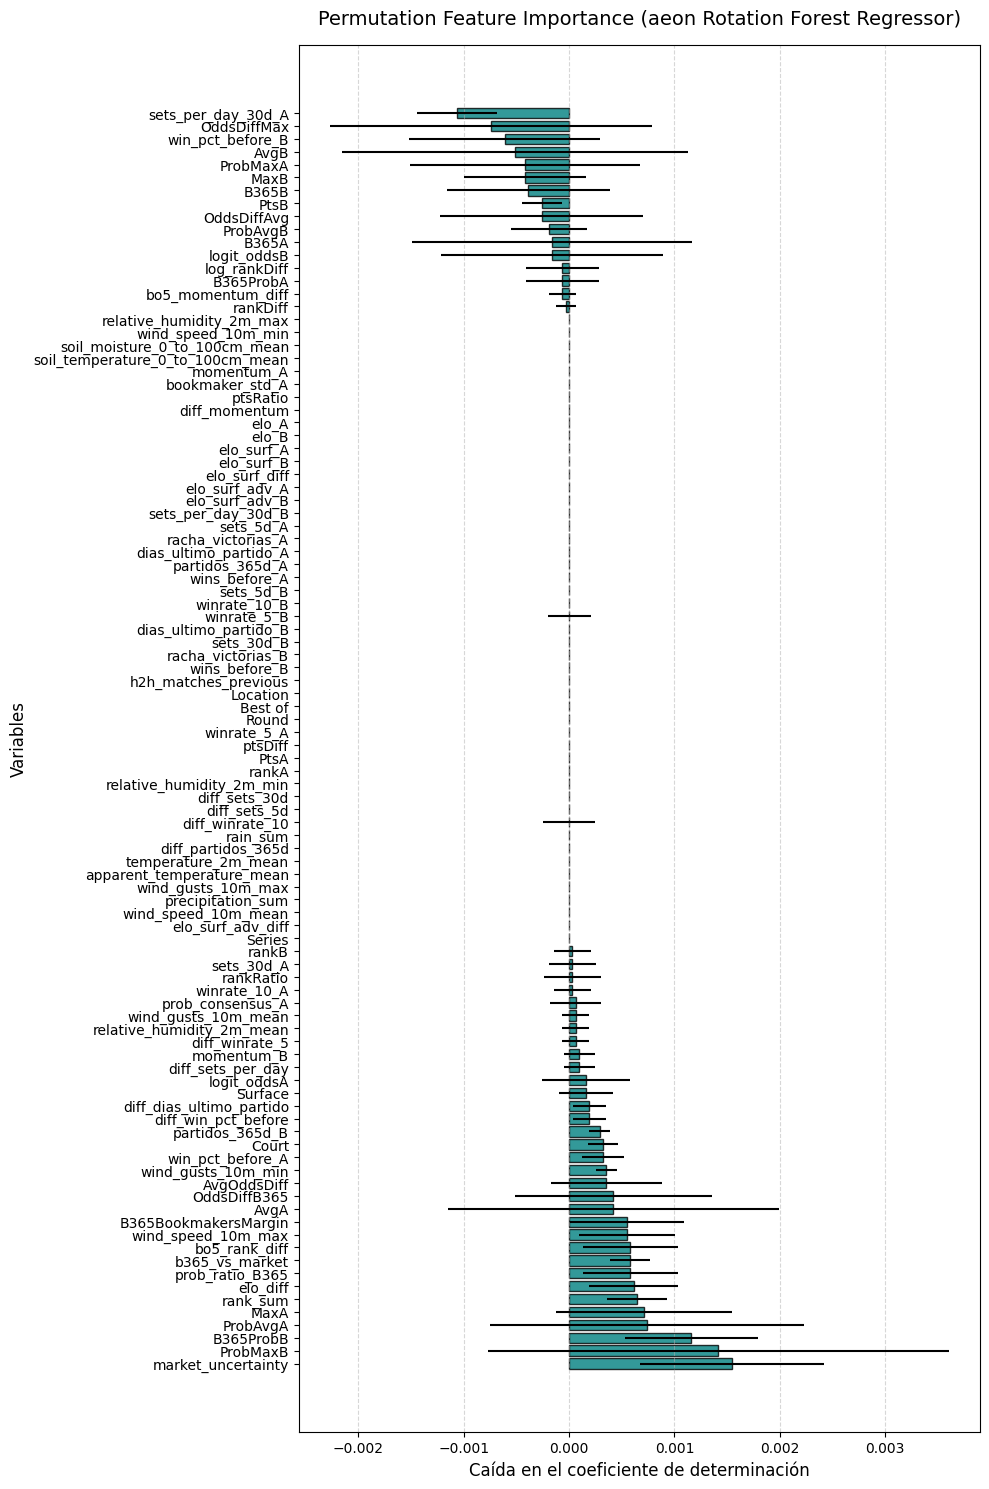

In [55]:
# 6. Graficar la Permutation Importance con barras de error
perm_importance_df = perm_importance_df.sort_values(by='Importance Mean', ascending=False)
plt.figure(figsize=(10, 15))
plt.barh(
    perm_importance_df['Feature Id'],
    perm_importance_df['Importance Mean'],
    xerr=perm_importance_df['Importance Std'],
    color='teal',
    edgecolor='black',
    alpha=0.8
)
plt.title("Permutation Feature Importance (aeon Rotation Forest Regressor)", fontsize=14, pad=15)
plt.xlabel("Caída en el coeficiente de determinación", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Modelo reducido 1

In [56]:
X_bis = df[perm_importance_df[perm_importance_df['Importance Mean'] > 0]['Feature Id'].values].dropna()

In [57]:
X_train_bis, X_test_bis, y_train_bis, y_test_bis = train_test_split(X_bis, y, train_size=0.8, random_state=random_state)

cat_features = X_train_bis.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train_bis, y_train_bis, cat_features=cat_features)

In [58]:
catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='AUC',
    # use_best_model=True,
    random_seed=42,
    verbose=100
)

catboost.fit(train_pool)

0:	total: 16.4ms	remaining: 16.4s
100:	total: 1.49s	remaining: 13.2s
200:	total: 2.94s	remaining: 11.7s
300:	total: 4.9s	remaining: 11.4s
400:	total: 8.07s	remaining: 12.1s
500:	total: 10.3s	remaining: 10.3s
600:	total: 13.4s	remaining: 8.92s
700:	total: 16.7s	remaining: 7.11s
800:	total: 20.3s	remaining: 5.03s
900:	total: 23.4s	remaining: 2.57s
999:	total: 25.9s	remaining: 0us


CatBoostClassifier(eval_metric='AUC', iterations=1000, learning_rate=0.02, loss_function='Logloss', random_seed=42, verbose=100)

In [61]:
print('\nTRAIN')
y_pred = catboost.predict(X_train_bis)
print(accuracy_score(y_train_bis, y_pred))

print('\nTEST')
y_pred = catboost.predict(X_test_bis)
print(accuracy_score(y_test_bis, y_pred))


TRAIN
0.7694972607154367

TEST
0.7239046391752577


## Hyperparameter Tuning with GridSearchCV

To further optimize the CatBoost model, we can perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination to determine which yields the best performance. This helps in finding a more robust and generalized model configuration.

In [49]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# These ranges are chosen to explore around the current values and common best practices.
param_grid = {
    'iterations': [500, 1000], # saco 1500
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [3, 5] # saco 1
}

# Initialize CatBoostClassifier with some base parameters
cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=random_state,
    verbose=False, # Set to False to reduce GridSearchCV output verbosity
    use_best_model=True,
    early_stopping_rounds=500
)

# Initialize GridSearchCV
# We'll use accuracy as the scoring metric and 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=2, # Use 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_val, y_val))

print("GridSearchCV finished.")

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best accuracy score found: {grid_search.best_score_}")

Starting GridSearchCV...
Fitting 2 folds for each of 36 candidates, totalling 72 fits
GridSearchCV finished.
Best parameters found: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best accuracy score found: 0.701278591559125


## Model Training with Best Parameters

Now that we have identified the optimal hyperparameters using GridSearchCV, we will train a new CatBoost model using these best parameters. This optimized model is expected to provide better performance compared to the previously trained model with default or manually chosen parameters.

In [50]:
# Train a new CatBoost model with the best parameters found by GridSearchCV
catboost_optimized = CatBoostClassifier(
    **grid_search.best_params_,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=random_state,
    verbose=100,
    use_best_model=True
)

# Ensure train_pool and val_pool are correctly defined for the optimized model
# Assuming X_train, y_train, X_val, y_val, and cat_features are already defined from previous cells
optimized_train_pool = Pool(X_train, y_train, cat_features=cat_features)
optimized_val_pool = Pool(X_val, y_val, cat_features=cat_features)

print("Training optimized CatBoost model...")
catboost_optimized.fit(optimized_train_pool, eval_set=optimized_val_pool)
print("Optimized CatBoost model training complete.")

Training optimized CatBoost model...
0:	learn: 0.7030920	test: 0.7015707	best: 0.7015707 (0)	total: 75.7ms	remaining: 37.8s
100:	learn: 0.7418673	test: 0.7023762	best: 0.7080145 (6)	total: 6.77s	remaining: 26.7s
200:	learn: 0.7883976	test: 0.6971406	best: 0.7080145 (6)	total: 12.7s	remaining: 18.9s
300:	learn: 0.8378487	test: 0.6983488	best: 0.7080145 (6)	total: 19.4s	remaining: 12.8s
400:	learn: 0.8818612	test: 0.6999597	best: 0.7080145 (6)	total: 25.4s	remaining: 6.26s
499:	learn: 0.9151979	test: 0.6995570	best: 0.7080145 (6)	total: 32.1s	remaining: 0us

bestTest = 0.7080144986
bestIteration = 6

Shrink model to first 7 iterations.
Optimized CatBoost model training complete.


## Optimized Model Evaluation

Let's evaluate the performance of the CatBoost model trained with the best parameters found through GridSearchCV on the training, validation, and test sets. We will look at accuracy to compare it with previous models and baselines.

In [51]:
print('\nOPTIMIZED MODEL EVALUATION')

print('\nTRAIN SET (Optimized Model)')
y_pred_train_optimized = catboost_optimized.predict(X_train)
print(f'Accuracy: {accuracy_score(y_train, y_pred_train_optimized)}')

print('\nVALIDATION SET (Optimized Model)')
y_pred_val_optimized = catboost_optimized.predict(X_val)
print(f'Accuracy: {accuracy_score(y_val, y_pred_val_optimized)}')

print('\nTEST SET (Optimized Model)')
y_pred_test_optimized = catboost_optimized.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred_test_optimized)}')
print('\nClassification Report on Test Set:')
print(classification_report(y_test, y_pred_test_optimized))


OPTIMIZED MODEL EVALUATION

TRAIN SET (Optimized Model)
Accuracy: 0.7071205559472253

VALIDATION SET (Optimized Model)
Accuracy: 0.7080144985904149

TEST SET (Optimized Model)
Accuracy: 0.727770618556701

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1601
           1       0.71      0.74      0.72      1503

    accuracy                           0.73      3104
   macro avg       0.73      0.73      0.73      3104
weighted avg       0.73      0.73      0.73      3104



## Conclusión:

No se pudo obtener tampoco con este un accuracy superior a las cuotas de mercado. Por ende, no encontramos un algoritmo que venza al mercado.

Queda ver la compración del rendimiento de las predicciones con más de 70% de confianza y el análisis de Value Bets que es cuando difiere la probabilidad asignada por el modelo vs la probabilidad asignada por el mercado.